## Introducción

Como analista de datos, mi objetivo fue **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajaré con datos reales de TomTom Traffic Index y OECD Cities, los cuales limpié, combiné y analizé para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es  necesario **familiarizase con la estructura de ambos datasets**.
En esta etapa, validaremos que los archivos se carguen correctamente, conoceremos sus columnas y tipos de datos, y se detectarán posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Desarrollo:**
- Importo las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Cargo los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guardo los DataFrames en las variables `traffic` y `eco`.
- Muestro las primeras 5 filas de cada DataFrame.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargo los archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
traffic.head()  #muestro  las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head()  #muestro las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciono su estructura, tipos de datos, columnas y valores faltantes.
Anoto las columnas que necesiten limpieza y luego estandarizo los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.


**Desarrollo:**
- Uso `.info()` para conocer la estructura de ambos DataFrames.
- Muestro los primeros 3 renglones de cada DF.
- Identifico si los detalles de cada DF estan bien o si requieren correcciones y escribo mis conclusiones en el bloque Markdown.



In [ ]:
traffic.info() # Examino la estructura de traffic


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
eco.info() # Examino la estructura de eco


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Desarrollo:**

- Cambio los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifico que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
traffic = traffic.rename(columns = {"Country": "country", "UpdateTimeUTC": "update_time_utc" ,"UpdateTimeUTCWeekAgo": "update_time_utc_week_ago"})# Estandarizar los nombres de las columnas de traffic


# verifico cambios
traffic.columns

Index(['country', 'City', 'update_time_utc', 'JamsDelay', 'TrafficIndexLive',
       'JamsLengthInKms', 'JamsCount', 'TrafficIndexWeekAgo',
       'update_time_utc_week_ago', 'TravelTimeLivePer10KmsMins',
       'TravelTimeHistoricPer10KmsMins', 'MinsDelay'],
      dtype='object')

In [ ]:
eco = eco.rename(columns = {"Country": "country", "City GDP/capita": "city_gdp_capita", "Unemployment %": "unemployment_pct", "Population (M)": "population_m"}) # Estandarizar los nombres de las columnas de eco


# verifico cambios
eco.columns

Index(['Year', 'City', 'country', 'city_gdp_capita', 'unemployment_pct',
       'PM2.5 (μg/m³)', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Desarrollo:**

- Convierto las columnas de fecha de `traffic` a formato `datetime`. Hago el cambio a prueba de errores.
- En el dataset `eco`, limpio los valores numéricos:
    - En `city_gdp_capita`: elimino separadores de miles (`.`) y reemplazo las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimino el símbolo de porcentaje (`%`) y reemplazo las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplazo las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, creo una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [ ]:
# Convierto las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors="coerce", utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors="coerce", utc=True)

# verifico el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype              
---  ------                          --------------    -----              
 0   country                         1004464 non-null  object             
 1   City                            1004464 non-null  object             
 2   update_time_utc                 1004464 non-null  datetime64[ns, UTC]
 3   JamsDelay                       1004464 non-null  float64            
 4   TrafficIndexLive                1004464 non-null  float64            
 5   JamsLengthInKms                 1004464 non-null  float64            
 6   JamsCount                       1004464 non-null  float64            
 7   TrafficIndexWeekAgo             1004464 non-null  float64            
 8   update_time_utc_week_ago        1004464 non-null  datetime64[ns, UTC]
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64

In [ ]:
# Limpio separadores y convierto columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calculo la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verifico el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              30 non-null     int64  
 1   City              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   PM2.5 (μg/m³)     30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,Year,City,country,city_gdp_capita,unemployment_pct,PM2.5 (μg/m³),population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Desarrollo**

- Como el DataFrame `traffic` no tiene una columna de año, utilizo el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtro las filas donde el año sea **2024**.
- Utilizo `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraigo el año de las fechas en update_time_utc
traffic['year'] = pd.to_datetime(traffic["update_time_utc"]).dt.year

# Verifico cambio
traffic.head(3)

,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,update_time_utc_week_ago,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtro los registros del año 2024
traffic_2024 = traffic[traffic["year"]==2024].copy()
eco = eco.rename(columns={"City": "city", "Year": "year"})
eco_2024 = eco[eco["year"]==2024].copy()

# Reviso dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,update_time_utc_week_ago,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,PM2.5 (μg/m³),population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calculo los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Desarrollo**

- Agrupo los datos por `city`, `country` y `year`.
- Calculo el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guardo el resultado como `traffic_city_year_2024`, manteniendo las columnas como variables (no índices).


In [ ]:
# Calculo los  promedios de trafico por ciudad, país y año
traffic= traffic.rename(columns={"City": "city", "Year": "year"})
traffic_city_year_2024 = traffic.groupby(["city","country", "year"]).agg({"JamsDelay": "mean",
    "TrafficIndexLive": "mean",
    "JamsLengthInKms": "mean",
    "JamsCount": "mean",
    "MinsDelay": "mean",
    "TravelTimeLivePer10KmsMins": "mean",
    "TravelTimeHistoricPer10KmsMins": "mean"}).reset_index() # tu código aqui

# Muestro resultados
traffic_city_year_2024.head()

,city,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,a-coruna,ESP,2025,11.323684,11.055921,1.161513,3.105263,0.402193,15.839864,15.437671
2,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
3,aachen,DEU,2025,16.278289,18.269737,3.400000,4.144737,0.648249,13.347184,12.698935
4,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016


### 🧠 **Vamos a descubrir que ciudad tiene el mayor timpo Promedio de tráfico**

Para descubrir que ciudad tiene el mayor tiempo promedio de tráfico ejecuto el siguiente código

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`



In [ ]:
traffic_city_year_2024.sort_values(["JamsDelay"], ascending=False)

,city,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins
442,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
704,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
492,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
400,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
422,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
25,almere,NLD,2025,1.833667,5.040000,0.214333,0.596667,-0.063112,9.455774,9.518886
223,dunedin,NZL,2025,1.644408,11.023026,0.306250,0.526316,0.101581,15.436593,15.335011
291,hamilton,NZL,2025,1.448658,7.892617,0.161745,0.473154,-0.197995,13.097767,13.295761
234,el-paso,USA,2024,0.299024,2.340435,0.031114,0.078118,-0.250676,10.690269,10.940945


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México con 2,833.06 minutos de retraso promedio por congestión.


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets nos permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Desarrollo**
- Selecciono solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Uso `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Uno ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantengo solo las ciudades y años presentes en ambos datasets.
- Guardo el resultado en una nueva variable llamada `merged` y muestro las primeras 5 filas.


In [ ]:
# Selecciono columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Uso .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[["city", "year","JamsDelay",
                                           "TrafficIndexLive","JamsLengthInKms",
                                           "JamsCount","MinsDelay",
                                           "TravelTimeLivePer10KmsMins"]].copy()
eco_2024_small = eco_2024[["city", "year","city_gdp_capita","unemployment_pct","population"]].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small, on=["city","year"], how="inner") # tu código aquí

merged.head() # Muestro las primeras 5 filas


,city,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,city_gdp_capita,unemployment_pct,population
0,belo-horizonte,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,11124.0,9.5,6100000.0
1,bogota,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,11442.0,10.0,11300000.0
2,brasilia,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,16251.0,7.8,4800000.0
3,buenos-aires,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,18117.0,7.2,15400000.0
4,curitiba,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,12381.0,8.2,3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tenemos un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Desarrollo**
- Uso las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualizo la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualizo la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **comparo ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.


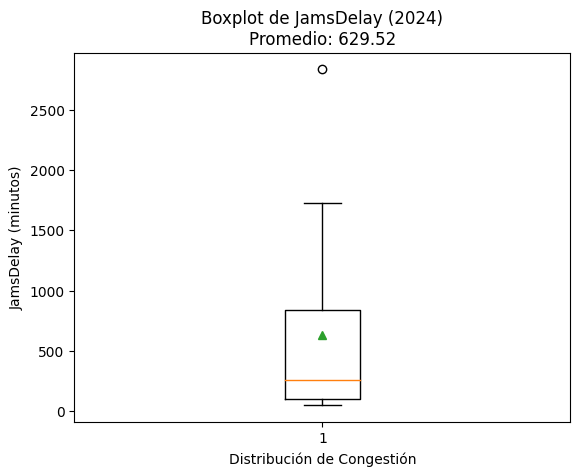

In [ ]:
# Creo boxplot para observar el comportamiento de los minutos de congestion JamsDelay
plt.boxplot(merged['JamsDelay'], showmeans=True)
plt.ylabel('JamsDelay (minutos)')
plt.xlabel('Distribución de Congestión')

# obtengo promedio para mostrarlo en título
mean_value = merged['JamsDelay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


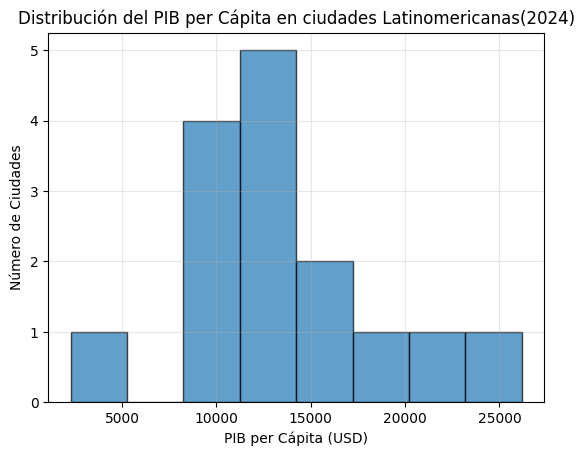

In [ ]:
# Creo histograma para ver la distribución de la economía (city_gdp_capita)
merged["city_gdp_capita"].hist(bins=8, edgecolor="black", alpha=0.7)
figsize =(10,5)
plt.title("Distribución del PIB per Cápita en ciudades Latinomericanas(2024)")
plt.xlabel("PIB per Cápita (USD)")
plt.ylabel("Número de Ciudades")
plt.grid(True, alpha=0.3)
plt.show()

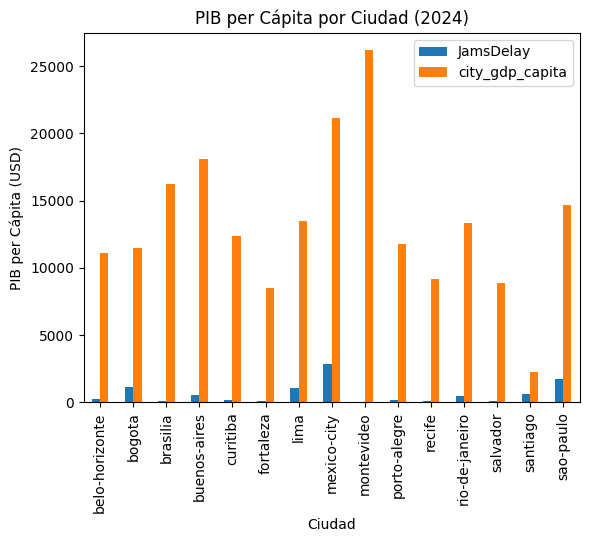

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(x="city" , y=['JamsDelay', 'city_gdp_capita'], kind="bar")
plt.title("PIB per Cápita por Ciudad (2024)")
plt.xlabel("Ciudad")
plt.ylabel("PIB per Cápita (USD)")
plt.xticks(rotation=90)
plt.show()

### 🧠 **Relación entre PIP per cápita y congestión**
Revisando los gráficos podemos observar si las ciudades con mayor PIB per cápita también presentan más congestión o sucede lo contrario, o no existe una elación clara?.

No existe una relación directa simple entre PIB y la congestión. Los datos muestran patrones más complejos como por ejemplo Buenos aires tiene PIP per cápita de 18 117 USD y presenta una congestión de 571 minutos aí como Brasilia con PIP per Cápita de  16 251 USD con congestión baja de 101 minutos. Sin embargo Bogotá tiene PIP per cápita de 11 442 USD pero una congestión muy alta de 1 141 minutos. Existen otros factores que influyen en estos resultados como la planificación urbana, la geografía, la inversión en transporte público y la densidad poblacional. La correlación estadística entre ambas variables es débil. Las políticas de transporte son más determinantes que la riqueza económica.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final se consolida todo el trabajo: se guarda el dataset limpio y se crea un resumen documentando los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.



In [ ]:
# Exporto el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

**Resumen Ejecutivo: **

Este análisis evalúa la relación entre movilidad urbana y productividad económica en ciudades latinoamericanas durante 2024. El objetivo fue identificar ciudades prioritarias para inversión en infraestructura de transporte, utilizando datos de congestión vehicular (TomTom) e indicadores económicos (OECD). El análisis reveló que no existe una correlación lineal clara entre el PIB per cápita y los niveles de congestión vehicular demostrando que no por ser ciudades más ricas automáticamente tienen mejor movilidad.

**Variables Claves Utilizadas de Movilidad:**
JamsDelay: Tiempo de retraso por congestión (minutos),
TrafficIndexLive: Índice de tráfico en tiempo real,
TravelTimeLivePer10KmsMins: Tiempo de viaje por cada 10 km.

**Variables Claves Económicas:**
city_gdp_capita: PIB per cápita (USD),
unemployment_pct: Tasa de desempleo,
population: Población total.

**Cobertura de datos:**
Se analizaron 15 ciudades latinoamericanas con datos completos para 2024, abarcando 7 países: Argentina, Brasil, Colombia, México, Perú, Uruguay y Chile. Los datasets se integraron mediante unión INNER para garantizar información completa. Se estandarizaron formatos con la conversión de columnas de fecha a datetime64, limpieza de separadores numéricos (puntos y comas) y eliminación de símbolos de porcentaje así como la transformación de variables económicas de object a float64 para permitir cálculos. A través de la  agregación de ciudad-año se calcularon los promedios anuales de métricas de tráfico para consolidar múltiples registros diarios por ciudad.
Se integraron los datasets de tráfico (TomTom) y economía (OECD) manteniendo solo ciudades presentes en ambas fuentes con la uniñon INNER. Como validaciones visuales se desarrolló un Boxplot de congestión (JamsDelay) e histograma de PIB per cápita asi como un
Gráfico de barras comparativo entre variables económicas y de movilidad

**Hallazgos iniciales:**
No existe correlación directa entre PIB per cápita y congestión vehicular. Ciudad de México presenta la congestión más extrema (2,833 minutos con PIB 21 111 USD), mientras Bogotá muestra alta congestión (1,141 minutos) con PIB moderado ($11,442 USD). Brasilia destaca como caso excepcional: PIB alto (16,251 USD) pero congestión muy baja (101 min) debido a su diseño urbano planificado por lo que puede lograr simultaneamente alta productividad económica y baja congestión. La densidad poblacional por sí sola no determina la congestión, Buenos Aires (15.4M) maneja mejor el tráfico que Bogotá (11.3M), sugiriendo que la calidad de la infraestructura de transporte es más determinante que el tamaño de la población.  

**Recomendaciones:**

Ciudades prioritarias para inversión:
Ciudad de México, congestión crítica (2,833 minutos) requiere intervención urgente por la gran afectación a la población.
Bogotá, mejor relación costo-beneficio potencial (11,442 USD PIB, 1,141 minutos de congestión, nivel moderadamente alto).


**Acciones recomendadas:**
Desarrollar análisis de impacto económico detallado para Ciudad de México y Bogotá. Modelo a replicar Brasilia (caso de éxito en planificación), baja congestión (101 minutos) con PIB alto ($16,251 USD).
